In [24]:
import pandas as pd
import requests as r
import getpass, pprint, time, os, json
import geopandas as gpd


In [25]:
inDir = '/Users/tillweiss/Desktop/MODSNOW'          # IMPORTANT: Update if this does not reflect the proper directory on your OS
os.chdir(inDir)    
inDir

'/Users/tillweiss/Desktop/MODSNOW'

In [26]:
user = 'weiss14'     
password = "bemcog-bixqe3-bykpaZ"
api = 'https://appeears.earthdatacloud.nasa.gov/api/'  

In [27]:
token_response = r.post('{}login'.format(api), auth=(user, password)).json() # Insert API URL, call login service, provide credentials & return json
token_response

{'token_type': 'Bearer',
 'token': 'mejU0IcvCHKxhNKUNR_9D0BO4Js9vBE5apyFLIqnWhDFJlx2MZIP24fB2ieInzmhsD8TzZW5g9nirY7PW8jZCQ',
 'expiration': '2025-12-23T19:31:32Z'}

In [28]:
token = token_response['token']                      # Save login token to a variable
head = {'Authorization': 'Bearer {}'.format(token)}

In [29]:
product_response = r.get('{}product'.format(api)).json()                         # request all products in the product service
print('AρρEEARS currently supports {} products.'.format(len(product_response)))

AρρEEARS currently supports 144 products.


In [30]:
products = {p['ProductAndVersion']: p for p in product_response} # Create a dictionary indexed by product name & version
products['MOD13Q1.061']    

{'Product': 'MOD13Q1',
 'Platform': 'Terra MODIS',
 'Description': 'Vegetation Indices (NDVI & EVI)',
 'RasterType': 'Tile',
 'Resolution': '250m',
 'TemporalGranularity': '16 day',
 'Version': '061',
 'Available': True,
 'DocLink': 'https://doi.org/10.5067/MODIS/MOD13Q1.061',
 'Source': 'LP DAAC',
 'TemporalExtentStart': '2000-02-18',
 'TemporalExtentEnd': 'Present',
 'Deleted': False,
 'DOI': '10.5067/MODIS/MOD13Q1.061',
 'Info': {'provider_id': 'lp_prod'},
 'ProductAndVersion': 'MOD13Q1.061'}

In [31]:
prodNames = {p['ProductAndVersion'] for p in product_response} # Make list of all products (including version)
for p in prodNames:                                            # Make for loop to search list of products 'Description' for a keyword                
    if 'NDVI' in products[p]['Description']:
        pprint.pprint(products[p])

{'Available': True,
 'DOI': '10.5067/MODIS/MOD13A3.061',
 'Deleted': False,
 'Description': 'Vegetation Indices (NDVI & EVI)',
 'DocLink': 'https://doi.org/10.5067/MODIS/MOD13A3.061',
 'Info': {'provider_id': 'lp_prod'},
 'Platform': 'Terra MODIS',
 'Product': 'MOD13A3',
 'ProductAndVersion': 'MOD13A3.061',
 'RasterType': 'Tile',
 'Resolution': '1000m',
 'Source': 'LP DAAC',
 'TemporalExtentEnd': 'Present',
 'TemporalExtentStart': '2000-02-01',
 'TemporalGranularity': 'Monthly',
 'Version': '061'}
{'Available': True,
 'DOI': '10.5067/MODIS/MOD13A1.061',
 'Deleted': False,
 'Description': 'Vegetation Indices (NDVI & EVI)',
 'DocLink': 'https://doi.org/10.5067/MODIS/MOD13A1.061',
 'Info': {'provider_id': 'lp_prod'},
 'Platform': 'Terra MODIS',
 'Product': 'MOD13A1',
 'ProductAndVersion': 'MOD13A1.061',
 'RasterType': 'Tile',
 'Resolution': '500m',
 'Source': 'LP DAAC',
 'TemporalExtentEnd': 'Present',
 'TemporalExtentStart': '2000-02-18',
 'TemporalGranularity': '16 day',
 'Version': '06

In [32]:
prods = ['MOD13Q1.061']   

In [33]:
lst_response = r.get('{}product/{}'.format(api, prods[0])).json()  # Request layers for the 2nd product (index 1) in the list: MOD11A2.061
list(lst_response.keys())

['_250m_16_days_EVI',
 '_250m_16_days_MIR_reflectance',
 '_250m_16_days_NDVI',
 '_250m_16_days_NIR_reflectance',
 '_250m_16_days_VI_Quality',
 '_250m_16_days_blue_reflectance',
 '_250m_16_days_composite_day_of_the_year',
 '_250m_16_days_pixel_reliability',
 '_250m_16_days_red_reflectance',
 '_250m_16_days_relative_azimuth_angle',
 '_250m_16_days_sun_zenith_angle',
 '_250m_16_days_view_zenith_angle']

In [34]:
task_name = 'MODSNOW_irrigated'

# Shapefile

In [35]:
nps = gpd.read_file('/Users/tillweiss/Desktop/MODSNOW/data/Khorezm_region/khorezm_irrigated/khorezm_irrigated.shp')
print(nps.head()) 

   id  area_km2                                           geometry
0   0   35130.0  POLYGON ((58.66667 43, 58.66667 43.08333, 58.5...


In [53]:
nps_gc = nps[nps['id']==0]  
nps_gc = nps_gc[['geometry']].to_json() 
nps_gc = json.loads(nps_gc) 


In [54]:
projections = r.get('{}spatial/proj'.format(api)).json()  # Call to spatial API, return projs as json
projections 

[{'Name': 'native',
  'LongName': 'Native Projection',
  'Description': '',
  'Platforms': '',
  'Proj4': '',
  'Datum': '',
  'EPSG': '',
  'Units': '',
  'GridMapping': '',
  'Available': True},
 {'Name': 'geographic',
  'LongName': 'Geographic',
  'Description': '',
  'Platforms': "['SRTM', 'ECOSTRESS', 'SSEBop ET', 'GPW', 'ASTER GDEM', 'NASADEM', 'MEaSUREs LSTE', 'EMIT']",
  'Proj4': '+proj=longlat +datum=WGS84 +no_defs=True',
  'Datum': 'wgs84',
  'EPSG': 4326.0,
  'Units': 'degrees',
  'GridMapping': 'latitude_longitude',
  'Available': True},
 {'Name': 'sinu_modis',
  'LongName': 'MODIS Sinusoidal',
  'Description': '',
  'Platforms': "['Combined MODIS', 'Terra MODIS', 'Aqua MODIS', 'Suomi NPP VIIRS', 'NOAA-20 VIIRS', 'Global WELD']",
  'Proj4': '+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +R=6371007.181 +units=m +no_defs=True',
  'Datum': '',
  'EPSG': '',
  'Units': 'meters',
  'GridMapping': 'sinusoidal',
  'Available': True},
 {'Name': 'albers_weld_alaska',
  'LongName': 'WELD Albers 

In [55]:
projs = {}                                  # Create an empty dictionary
for p in projections: projs[p['Name']] = p  # Fill dictionary with `Name` as keys
list(projs.keys())  

['native',
 'geographic',
 'sinu_modis',
 'albers_weld_alaska',
 'albers_weld_conus',
 'albers_ard_alaska',
 'albers_ard_conus',
 'albers_ard_hawaii',
 'easegrid_2_global',
 'easegrid_2_north']

In [56]:
task_name = 'MODSNOW_irrigated'

In [57]:
projs['geographic']

{'Name': 'geographic',
 'LongName': 'Geographic',
 'Description': '',
 'Platforms': "['SRTM', 'ECOSTRESS', 'SSEBop ET', 'GPW', 'ASTER GDEM', 'NASADEM', 'MEaSUREs LSTE', 'EMIT']",
 'Proj4': '+proj=longlat +datum=WGS84 +no_defs=True',
 'Datum': 'wgs84',
 'EPSG': 4326.0,
 'Units': 'degrees',
 'GridMapping': 'latitude_longitude',
 'Available': True}

In [ ]:
task_type = 'area'
proj = projs['geographic']['Name'] 
outFormat = ['geotiff', 'netcdf4']  # Set output file format type
startDate = "01-01-2025"         # Start of the date range for which to extract data: MM-DD-YYYY
endDate = "01-30-2025"                 # End of the date range for which to extract data: MM-DD-YYYY
recurring = False                   # Specify True for a recurring date range
#yearRange = [2000,2016]         # if recurring = True, set yearRange, change start/end date to MM-DD

In [80]:
years = range(2000,2025,1)
years

range(2000, 2025)

In [ ]:
task = {
    'task_type': task_type,
    'task_name': task_name,
    'params': {
         'dates': [
         {
             'startDate': startDate,
             'endDate': endDate
         }],
        "layers": [
            {
                "product": "MOD13Q1.061",
                "layer": "_250m_16_days_NDVI",
    }],
    "qualityFilters": {
    "MOD13Q1.061": {
        "SummaryQA": [0]
    }
},
         'output': {
                 'format': {
                         'type': outFormat[1]}, 
                         'projection': proj},
         'geo': nps_gc,
    }
}

In [71]:
task_response = r.post('{}task'.format(api), json=task, headers=head).json()  # Post json to the API task service, return response as json
task_response     

{'task_id': 'd7c3e86c-2efd-4cc7-aa5b-623087443a65', 'status': 'pending'}

In [72]:
params = {'limit': 2, 'pretty': True} 

In [73]:
task_id = task_response['task_id']                                               # Set task id from request submission
status_response = r.get('{}status/{}'.format(api, task_id), headers=head).json() # Call status service with specific task ID & user credentials

In [74]:
# Ping API until request is complete, then continue to Section 4
starttime = time.time()
while r.get('{}task/{}'.format(api, task_id), headers=head).json()['status'] != 'done':
    print(r.get('{}task/{}'.format(api, task_id), headers=head).json()['status'])
    time.sleep(20.0 - ((time.time() - starttime) % 20.0))
print(r.get('{}task/{}'.format(api, task_id), headers=head).json()['status'])

queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
queued
processing
processing
done


In [75]:
destDir = os.path.join(inDir, task_name)                # Set up output directory using input directory and task name
if not os.path.exists(destDir):os.makedirs(destDir)  

In [76]:
bundle = r.get('{}bundle/{}'.format(api,task_id), headers=head).json()  # Call API and return bundle contents for the task_id as json
bundle

{'files': [{'sha256': 'fae2b6d21bfc453a4f510933e8e0aeb98b8513012103289dc34aaeeb65b46e19',
   'file_id': 'b26ff4bb-10ba-400d-9210-58c06ec952cc',
   'file_name': 'MOD13Q1.061_2024352_to_2025030/MOD13Q1.061__250m_16_days_NDVI_doy2024353000000_aid0001.tif',
   'file_size': 2320630,
   'file_type': 'tif',
   's3_url': 's3://appeears-output/d7c3e86c-2efd-4cc7-aa5b-623087443a65/MOD13Q1.061_2024352_to_2025030/MOD13Q1.061__250m_16_days_NDVI_doy2024353000000_aid0001.tif'},
  {'sha256': '51b1df671c5bad545f67ba733e80ebd4a5bc83673916ea8c206b792174c7995a',
   'file_id': '00e876fc-e7ea-43f9-bd48-5226e90c2e0e',
   'file_name': 'MOD13Q1.061_2024352_to_2025030/MOD13Q1.061__250m_16_days_NDVI_doy2025001000000_aid0001.tif',
   'file_size': 2281789,
   'file_type': 'tif',
   's3_url': 's3://appeears-output/d7c3e86c-2efd-4cc7-aa5b-623087443a65/MOD13Q1.061_2024352_to_2025030/MOD13Q1.061__250m_16_days_NDVI_doy2025001000000_aid0001.tif'},
  {'sha256': '91414afbe6728d8cf779ccf1ad9de27e98f263d0aabb2b9074300c6c90d

In [77]:
files = {}                                                       # Create empty dictionary
for f in bundle['files']: files[f['file_id']] = f['file_name']   # Fill dictionary with file_id as keys and file_name as values
files    

{'b26ff4bb-10ba-400d-9210-58c06ec952cc': 'MOD13Q1.061_2024352_to_2025030/MOD13Q1.061__250m_16_days_NDVI_doy2024353000000_aid0001.tif',
 '00e876fc-e7ea-43f9-bd48-5226e90c2e0e': 'MOD13Q1.061_2024352_to_2025030/MOD13Q1.061__250m_16_days_NDVI_doy2025001000000_aid0001.tif',
 '05613b5e-d2a2-4905-a16b-196480e88759': 'MOD13Q1.061_2024352_to_2025030/MOD13Q1.061__250m_16_days_NDVI_doy2025017000000_aid0001.tif',
 '7bf3bb0e-237c-4c96-a13c-904280d9a721': 'MOD13Q1.061_2024352_to_2025030/MOD13Q1.061__250m_16_days_VI_Quality_doy2024353000000_aid0001.tif',
 'f52a954e-9cd6-40c8-aaa9-1878acacf50b': 'MOD13Q1.061_2024352_to_2025030/MOD13Q1.061__250m_16_days_VI_Quality_doy2025001000000_aid0001.tif',
 '793b6c67-b857-48fb-97d6-77f4cf677f12': 'MOD13Q1.061_2024352_to_2025030/MOD13Q1.061__250m_16_days_VI_Quality_doy2025017000000_aid0001.tif',
 '368a113f-143f-4921-9279-27d7182da4ef': 'MOD13Q1-061-250m-16-days-VI-Quality-lookup.csv',
 '107bfa79-5983-4f54-ac45-265740b7c9cc': 'MOD13Q1-061-250m-16-days-VI-Quality-Sta

In [78]:
for f in files:
    dl = r.get('{}bundle/{}/{}'.format(api, task_id, f), headers=head, stream=True, allow_redirects = 'True')                                # Get a stream to the bundle file
    if files[f].endswith('.tif'):
        filename = files[f].split('/')[1]
    else:
        filename = files[f] 
    filepath = os.path.join(destDir, filename)                                                       # Create output file path
    with open(filepath, 'wb') as f:                                                                  # Write file to dest dir
        for data in dl.iter_content(chunk_size=8192): f.write(data) 
print('Downloaded files can be found at: {}'.format(destDir))

Downloaded files can be found at: /Users/tillweiss/Desktop/MODSNOW/MODSNOW_irrigated


In [88]:
# Configuration
# ----------------------------
task_name = 'MODSNOW_irrigated_MarJul_2000_2024'
task_type = 'area'
proj = projs['geographic']['Name']
outFormat = ['geotiff', 'netcdf4']
recurring = False

# Use a single continuous date range (API-safe)
startDate = "03-01-2000"
endDate   = "08-31-2025"

# ----------------------------
# Task definition
# ----------------------------
task = {
    'task_type': task_type,
    'task_name': task_name,
    'params': {
        'dates': [{
            'startDate': startDate,
            'endDate': endDate
        }],
        'layers': [
            {
                'product': 'MOD13Q1.061',
                'layer': '_250m_16_days_NDVI'
            }
        ],
        'qualityFilters': {
            'MOD13Q1.061': {
                'SummaryQA': [0]
            }
        },
        'output': {
            'format': {'type': outFormat[1]},  # netcdf4
            'projection': proj
        },
        'geo': nps_gc
    }
}


# ----------------------------
# Submit task
# ----------------------------
task_response = r.post(f'{api}task', json=task, headers=head).json()

if 'task_id' not in task_response:
    raise RuntimeError(f"Task submission failed: {task_response}")

task_id = task_response['task_id']
print(task_id)

# ----------------------------
# Monitor task
# ----------------------------
#starttime = time.time()
#while r.get(f'{api}task/{task_id}', headers=head).json()['status'] != 'done':
#    status = r.get(f'{api}task/{task_id}', headers=head).json()['status']
#    print(status)
#    time.sleep(20.0 - ((time.time() - starttime) % 20.0))

print('done')

# ----------------------------
# Download results
# ----------------------------
#destDir = os.path.join(inDir, task_name)
#os.makedirs(destDir, exist_ok=True)

#bundle = r.get(f'{api}bundle/{task_id}', headers=head).json()

#files = {f['file_id']: f['file_name'] for f in bundle['files']}

#for file_id, fname in files.items():
#    dl = r.get(
#        f'{api}bundle/{task_id}/{file_id}',
#        headers=head,
#        stream=True,
#        allow_redirects=True
#    )

#    filename = fname.split('/')[-1]
#    filepath = os.path.join(destDir, filename)

 #   with open(filepath, 'wb') as out:
  #      for chunk in dl.iter_content(chunk_size=8192):
   #         out.write(chunk)

#print(f'Downloaded files can be found at: {destDir}')


c52aa472-76d2-48e2-9464-002abb75c54e
done


In [90]:
task_id = 'c52aa472-76d2-48e2-9464-002abb75c54e'

status = r.get(f'{api}task/{task_id}', headers=head).json()['status']
print(f"Current task status: {status}")

Current task status: queued


In [91]:
task_name = 'MODSNOW_irrigated_MarJul_2000_2024'
destDir = os.path.join(inDir, task_name)
os.makedirs(destDir, exist_ok=True)

bundle = r.get(f'{api}bundle/{task_id}', headers=head).json()

files = {f['file_id']: f['file_name'] for f in bundle['files']}

for file_id, fname in files.items():
    dl = r.get(
        f'{api}bundle/{task_id}/{file_id}',
        headers=head,
        stream=True,
        allow_redirects=True
    )

    filename = fname.split('/')[-1]
    filepath = os.path.join(destDir, filename)

    with open(filepath, 'wb') as out:
        for chunk in dl.iter_content(chunk_size=8192):
            out.write(chunk)

print(f"Download complete. Files are in:\n{destDir}")


Download complete. Files are in:
/Users/tillweiss/Desktop/MODSNOW/MODSNOW_irrigated_MarJul_2000_2024


In [ ]:
/Users/tillweiss/Desktop/MODSNOW/data/cloud_snow_fraction_amudarya_kerky_4report.txt

In [295]:
ndvi = pd.read_csv('/Users/tillweiss/Desktop/MODSNOW/MODSNOW_irrigated_MarJul_2000_2024/MOD13Q1-061-Statistics.csv')

ndvi['Date'] = pd.to_datetime(ndvi['Date'])
ndvi = ndvi[['Date', 'Mean']]
ndvi = ndvi.rename(columns={'Mean': 'NDVI'})

In [296]:
ndvi

,Date,NDVI
0,2000-02-18,0.100339
1,2000-03-05,0.104449
2,2000-03-21,0.115389
3,2000-04-06,0.149180
4,2000-04-22,0.203452
...,...,...
583,2025-06-26,0.316781
584,2025-07-12,0.343874
585,2025-07-28,0.358984
586,2025-08-13,0.356911


In [297]:
snow = pd.read_csv(
    '/Users/tillweiss/Desktop/MODSNOW/data/cloud_snow_fraction_amudarya_kerky_4report.txt',
    sep=';',
    header=None,
    engine='python'
)

print(snow.head())


      0   1     2      3   4
0  2000  57  0.90  54.58 NaN
1  2000  58  0.86  55.93 NaN
2  2000  59  0.80  56.73 NaN
3  2000  60  0.59  56.78 NaN
4  2000  61  0.27  56.29 NaN


In [298]:
snow.columns = ['Year', 'Day', 'Snow_Mean', 'Snow_Percent','nn']
snow['Snow_Mean'] = snow['Snow_Mean'].replace(-9, pd.NA)


In [299]:
snow['Date'] = pd.to_datetime(
    snow['Year'].astype(int).astype(str),
    format='%Y'
) + pd.to_timedelta(snow['Day'] - 1, unit='D')

snow = snow[['Date', 'Snow_Percent']]
snow

,Date,Snow_Percent
0,2000-02-26,54.58
1,2000-02-27,55.93
2,2000-02-28,56.73
3,2000-02-29,56.78
4,2000-03-01,56.29
...,...,...
9245,2025-06-20,6.18
9246,2025-06-21,8.12
9247,2025-06-22,5.59
9248,2025-06-23,6.48


In [300]:
ndvi_daily = ndvi[['Date', 'NDVI']].set_index('Date').resample('D').asfreq()
snow_daily = snow[['Date', 'Snow_Percent']].set_index('Date').resample('D').asfreq()

df = ndvi_daily.join(snow_daily, how='left')
df

,NDVI,Snow_Percent
Date,,
2000-02-18,0.100339,NaN
2000-02-19,NaN,NaN
2000-02-20,NaN,NaN
2000-02-21,NaN,NaN
2000-02-22,NaN,NaN
...,...,...
2025-08-25,NaN,NaN
2025-08-26,NaN,NaN
2025-08-27,NaN,NaN


In [301]:
df = df[df.index.month.isin([3, 4, 5, 6, 7, 8])]
df


,NDVI,Snow_Percent
Date,,
2000-03-01,NaN,56.29
2000-03-02,NaN,56.54
2000-03-03,NaN,57.37
2000-03-04,NaN,59.48
2000-03-05,0.104449,66.54
...,...,...
2025-08-25,NaN,NaN
2025-08-26,NaN,NaN
2025-08-27,NaN,NaN


In [302]:
snow_16d = []

ndvi_dates = df.index[df['NDVI'].notna()]

for d in ndvi_dates:
    window = df.loc[d : d + pd.Timedelta(days=15), 'Snow_Percent']
    snow_16d.append(window.mean())

df.loc[ndvi_dates, 'Snow_16d'] = snow_16d



/var/folders/lc/bq9k25r50ys8drfszqm3zdjc0000gn/T/ipykernel_4846/1749747336.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[ndvi_dates, 'Snow_16d'] = snow_16d


In [303]:
final = df.loc[ndvi_dates, ['NDVI', 'Snow_16d']].dropna()


In [304]:
final

,NDVI,Snow_16d
Date,,
2000-03-05,0.104449,53.382500
2000-03-21,0.115389,43.998750
2000-04-06,0.149180,33.395625
2000-04-22,0.203452,24.993125
2000-05-08,0.225870,13.888750
...,...,...
2025-04-07,0.202731,24.251250
2025-04-23,0.239482,26.625625
2025-05-09,0.262869,9.014375


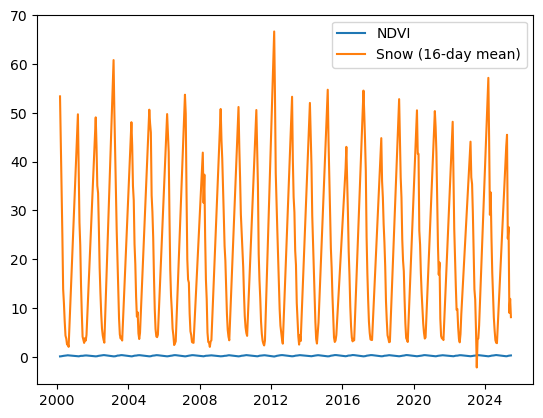

In [305]:
import matplotlib.pyplot as plt

final = final.reset_index()  
plt.plot(final['Date'], final['NDVI'], label='NDVI')
plt.plot(final['Date'], final['Snow_16d'], label='Snow (16-day mean)')
plt.legend()
plt.show()


In [306]:
import scipy.stats as stats
from scipy import stats


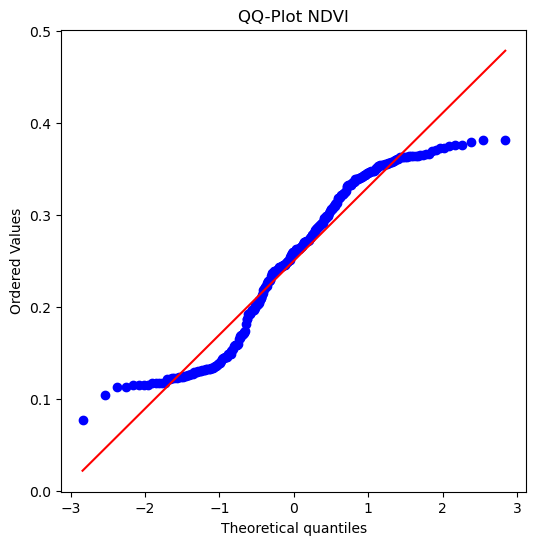

In [307]:
plt.figure(figsize=(6,6))
stats.probplot(final['NDVI'], dist="norm", plot=plt)
plt.title('QQ-Plot NDVI')
plt.show()

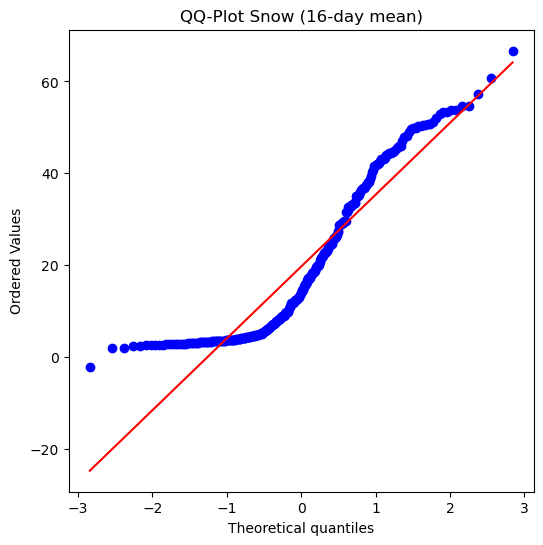

In [308]:
plt.figure(figsize=(6,6))
stats.probplot(final['Snow_16d'], dist="norm", plot=plt)
plt.title('QQ-Plot Snow (16-day mean)')
plt.show()

In [ ]:
ndvi_snow = final.copy()
ndvi_snow['Month'] = final['Date'].dt.month
ndvi_snow['Year'] = final['Date'].dt.year
ndvi_snow = ndvi_snow.dropna()

ndvi_snow

,Date,NDVI,Snow_16d,Month
0,2000-03-05,0.104449,53.382500,3
1,2000-03-21,0.115389,43.998750,3
2,2000-04-06,0.149180,33.395625,4
3,2000-04-22,0.203452,24.993125,4
4,2000-05-08,0.225870,13.888750,5
...,...,...,...,...
302,2025-04-07,0.202731,24.251250,4
303,2025-04-23,0.239482,26.625625,4
304,2025-05-09,0.262869,9.014375,5
305,2025-05-25,0.275582,11.900625,5


In [314]:
ndvi_snow = ndvi_snow.sort_values('Date')

march_snow = ndvi_snow[ndvi_snow['Month'] == 3].set_index('Year')['Snow_16d']
june_ndvi = ndvi_snow[ndvi_snow['Month'] == 6].set_index('Year')['NDVI']

In [315]:
aligned = march_snow.to_frame().join(june_ndvi, how='inner')
aligned

,Snow_16d,NDVI
Year,,
2000,53.382500,0.245400
2000,53.382500,0.268038
2000,43.998750,0.245400
2000,43.998750,0.268038
2001,49.710000,0.218970
...,...,...
2024,57.175625,0.305268
2024,44.317500,0.279082
2024,44.317500,0.305268


In [331]:
#march_snow = (
#    ndvi_snow[ndvi_snow['Month'] == 3]
#    .groupby('Year', as_index=False)['Snow_16d']
#    .mean()
#    .rename(columns={'Snow_16d': 'March_Snow'})
#)

march_snow = (
    ndvi_snow[ndvi_snow['Month'] == 3][['Year', 'Snow_16d']]
    .rename(columns={'Snow_16d': 'March_Snow'})
)

months = [3, 4, 5, 6, 7, 8]
month_names = ['March', 'April', 'May', 'June', 'July', 'August']


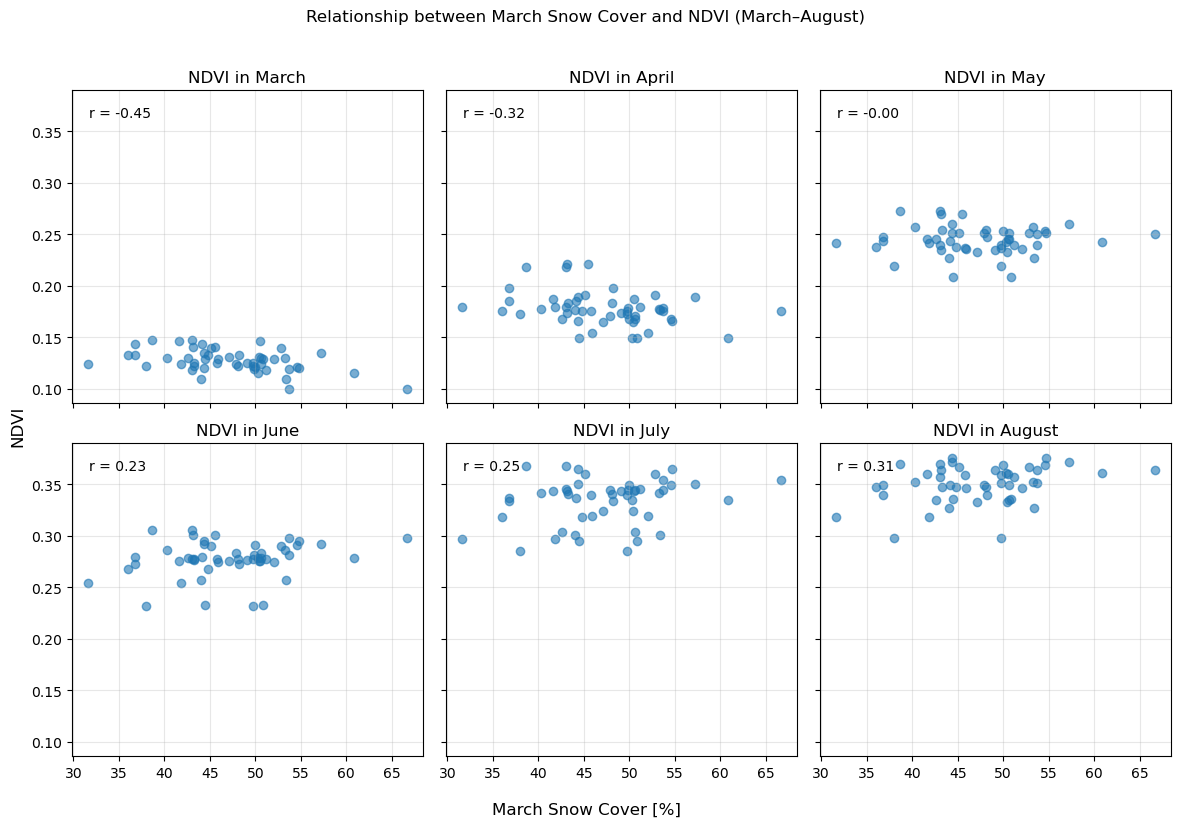

In [334]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, m, name in zip(axes, months, month_names):

    ndvi_m = (
        ndvi_snow[ndvi_snow['Month'] == m]
        .groupby('Year', as_index=False)['NDVI']
        .mean()
    )

    aligned = march_snow.merge(ndvi_m, on='Year', how='inner')

    ax.scatter(
        aligned['March_Snow'],
        aligned['NDVI'],
        alpha=0.6
    )

    ax.set_title(f'NDVI in {name}')
    ax.grid(True, alpha=0.3)
    r = aligned['March_Snow'].corr(aligned['NDVI'])
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes,
        va='top', ha='left')

fig.supxlabel('March Snow Cover [%]')
fig.supylabel('NDVI')
fig.suptitle('Relationship between March Snow Cover and NDVI (March–August)', y=1.02)

plt.tight_layout()
plt.show()

In [338]:
ndvi_snow

,Date,NDVI,Snow_16d,Month,Year
0,2000-03-05,0.104449,53.382500,3,2000
1,2000-03-21,0.115389,43.998750,3,2000
2,2000-04-06,0.149180,33.395625,4,2000
3,2000-04-22,0.203452,24.993125,4,2000
4,2000-05-08,0.225870,13.888750,5,2000
...,...,...,...,...,...
302,2025-04-07,0.202731,24.251250,4,2025
303,2025-04-23,0.239482,26.625625,4,2025
304,2025-05-09,0.262869,9.014375,5,2025
305,2025-05-25,0.275582,11.900625,5,2025


In [340]:
import pingouin as pg

pg.partial_corr(
    data=ndvi_snow,
    x='Snow_16d',
    y='NDVI',
    covar='Month'
)

,n,r,CI95%,p-val
pearson,307,-0.502912,"[-0.58, -0.41]",5.085411e-21


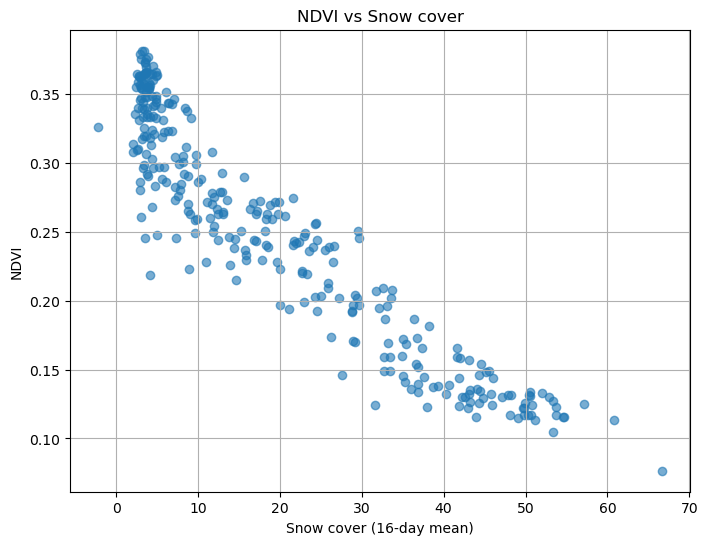

Pearson correlation: -0.937, p-value = 4.073e-141
Spearman correlation: -0.927, p-value = 1.168e-131


In [335]:
df_corr = ndvi_snow[['NDVI', 'Snow_16d']].dropna()
plt.figure(figsize=(8,6))
plt.scatter(df_corr['Snow_16d'], df_corr['NDVI'], alpha=0.6)
plt.xlabel('Snow cover (16-day mean)')
plt.ylabel('NDVI')
plt.title('NDVI vs Snow cover')
plt.grid(True)
plt.show()

# Pearson correlation
pearson_coef, pearson_p = stats.pearsonr(df_corr['Snow_16d'], df_corr['NDVI'])

# Spearman correlation
spearman_coef, spearman_p = stats.spearmanr(df_corr['Snow_16d'], df_corr['NDVI'])

print(f'Pearson correlation: {pearson_coef:.3f}, p-value = {pearson_p:.3e}')
print(f'Spearman correlation: {spearman_coef:.3f}, p-value = {spearman_p:.3e}')